<a href="https://colab.research.google.com/github/KiselevaStacy/python-ai--/blob/main/notebooks/week3_dogs_3d_combined.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/content/python-ai--
✅ Репозиторий готов

📊 Загружено строк в df_dogs: 2434
✅ df_dogs очищен

✅ Пород с полными данными по трём параметрам: 16
                       dogBreed_ru  mass_min  mass_max  height_min  \
38                  Чешский фоусек      22.0      34.0        58.0   
127            Вельш-корги пемброк       9.0      12.0        25.0   
218            Аляскинский маламут      34.0      38.0        58.5   
221  Американский водяной спаниель      11.5      20.5        38.0   
224         Американский фоксхаунд      30.0      34.0        53.0   
226           Анатолийская овчарка      40.0      65.0        71.0   
239               Афганская борзая      23.0      27.0        63.0   
240                    Аффенпинчер       4.0       6.0        25.0   
245                   Бассет-хаунд      32.0      32.0        33.0   
384               Немецкая овчарка      22.0      40.0        55.0   

     height_max  lifeExpectancy  
38         66.0            12.0  
127        30.0   

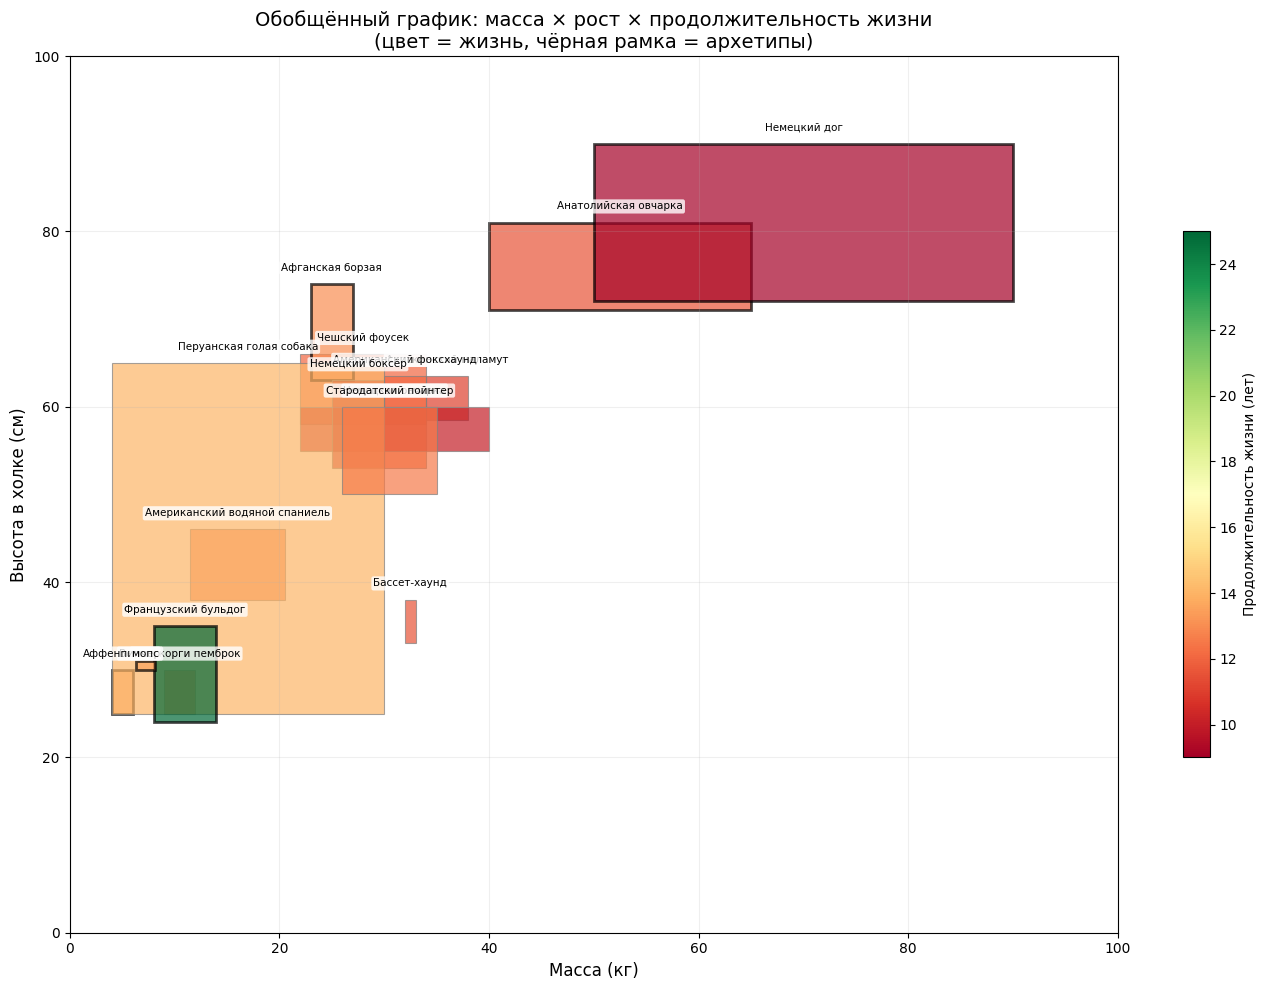


📊 Итоговая статистика:
   - Всего пород: 16
   - Диапазон жизни: 9.0 – 25.0 лет
   - Красный цвет → 9.0 лет (мало)
   - Зелёный цвет → 25.0 лет (много)


In [2]:
# Полный код третьего ноутбука (скопируйте в одну ячейку и выполните)

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors

# Клонируем репозиторий
repo_path = "/content/python-ai--"
if not os.path.exists(repo_path):
    !git clone -q https://github.com/KiselevaStacy/python-ai--.git
if os.getcwd() != repo_path:
    %cd python-ai--

print("✅ Репозиторий готов\n")

# Загружаем и чистим данные
df_dogs = pd.read_csv("data/dog_breeds.csv")
print(f"📊 Загружено строк в df_dogs: {len(df_dogs)}")

if "dogBreed" in df_dogs.columns:
    df_dogs = df_dogs.rename(columns={"dogBreed": "URL"})

technical_cols = ["heightQualifierLabel", "massQualifierLabel", "lifeExpectancyQualifierLabel",
                  "heightUnit", "massUnit", "lifeExpectancyUnit"]
cols_to_drop = [c for c in technical_cols if c in df_dogs.columns]
if cols_to_drop:
    df_dogs = df_dogs.drop(columns=cols_to_drop)

breed_col = None
for col in ["dogBreedLabel", "breedLabel", "Breed", "breed", "name", "label"]:
    if col in df_dogs.columns:
        breed_col = col
        break
if breed_col:
    df_dogs = df_dogs.rename(columns={breed_col: "dogBreed"})

for col in ["height", "mass", "lifeExpectancy"]:
    if col in df_dogs.columns:
        df_dogs[col] = pd.to_numeric(df_dogs[col], errors="coerce")

print("✅ df_dogs очищен\n")

# Группировка по породам
df_ranges = df_dogs.groupby('dogBreed').agg(
    mass_min=('mass', 'min'),
    mass_max=('mass', 'max'),
    height_min=('height', 'min'),
    height_max=('height', 'max'),
    lifeExpectancy=('lifeExpectancy', 'median')
).reset_index()

# Фильтруем породы с полными данными
df_combined = df_ranges[
    df_ranges['mass_min'].notna() &
    df_ranges['mass_max'].notna() &
    df_ranges['height_min'].notna() &
    df_ranges['height_max'].notna() &
    df_ranges['lifeExpectancy'].notna()
].copy()

print(f"✅ Пород с полными данными по трём параметрам: {len(df_combined)}")

# Перевод названий
BREED_TRANSLATIONS = {
    "Ariege Pointer":       "Арьежский пуантёр",
    "Cesky Fousek":         "Чешский фоусек",
    "Chippiparai":          "Чиппипарай",
    "Mudhol Hound":         "Мудхольская борзая",
    "Pembroke Welsh Corgi": "Вельш-корги пемброк",
}
df_combined["dogBreed_ru"] = df_combined["dogBreed"].replace(BREED_TRANSLATIONS)

print(df_combined[['dogBreed_ru', 'mass_min', 'mass_max', 'height_min', 'height_max', 'lifeExpectancy']].head(10))

# ============================================
# Финальный график
# ============================================

fig, ax = plt.subplots(figsize=(14, 10))

life_min = df_combined['lifeExpectancy'].min()
life_max = df_combined['lifeExpectancy'].max()
norm = mcolors.Normalize(vmin=life_min, vmax=life_max)
cmap = cm.RdYlGn

# Архетипы для выделения
archetypes = {
    'Борзые': ['Афганская борзая'],
    'Мастифы': ['Немецкий дог', 'Анатолийская овчарка'],
    'Декоративные': ['мопс', 'Аффенпинчер', 'Французский бульдог']
}

for _, row in df_combined.iterrows():
    mass_w = row['mass_max'] - row['mass_min']
    height_h = row['height_max'] - row['height_min']
    color = cmap(norm(row['lifeExpectancy']))

    # Проверяем архетип
    is_archetype = False
    for breeds in archetypes.values():
        if row['dogBreed'] in breeds:
            is_archetype = True
            break

    edgecolor = 'black' if is_archetype else 'gray'
    linewidth = 2 if is_archetype else 0.8

    rect = plt.Rectangle(
        (row['mass_min'], row['height_min']),
        max(mass_w, 1), max(height_h, 1),
        fill=True, facecolor=color, edgecolor=edgecolor,
        alpha=0.7, linewidth=linewidth
    )
    ax.add_patch(rect)

    # Подпись
    center_x = row['mass_min'] + max(mass_w, 1) / 2
    ax.annotate(row['dogBreed_ru'],
               (center_x, row['height_max'] + 1.5),
               ha='center', fontsize=7.5,
               bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8, ec='none'))

sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, label='Продолжительность жизни (лет)', shrink=0.6)

ax.set_xlabel('Масса (кг)', fontsize=12)
ax.set_ylabel('Высота в холке (см)', fontsize=12)
ax.set_title('Обобщённый график: масса × рост × продолжительность жизни\n(цвет = жизнь, чёрная рамка = архетипы)', fontsize=14)
ax.grid(True, alpha=0.2)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

print(f"\n📊 Итоговая статистика:")
print(f"   - Всего пород: {len(df_combined)}")
print(f"   - Диапазон жизни: {life_min:.1f} – {life_max:.1f} лет")
print(f"   - Красный цвет → {life_min:.1f} лет (мало)")
print(f"   - Зелёный цвет → {life_max:.1f} лет (много)")